In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch_geometric.data import Data
from torch_geometric.nn import ChebConv
import torch.nn.functional as F
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import preprocessing, metrics
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split
from sklearn.metrics import(
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    auc,
    precision_recall_curve,
    matthews_corrcoef,
)
from utils import *
import gseapy as gp

d:\Materials\ĐATN\Code\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
logging.basicConfig(
    level=print,
    format='%(levelname)s - %(message)s'
)

In [3]:
class GCNModel(nn.Module):
    def __init__(self, num_features, hidden_dim=256, output_dim=128, dropout=0.3):
        super().__init__()
        self.GCN1 = ChebConv(num_features, hidden_dim, K=2)
        self.GCN2 = ChebConv(hidden_dim, hidden_dim, K=2)
        self.GCN3 = ChebConv(hidden_dim, output_dim, K=2)
        self.dropout = nn.Dropout(dropout)
        self.LP = nn.Linear(num_features, hidden_dim)
        self.ln1 = nn.LayerNorm(num_features, elementwise_affine=False)
        self.ln2 = nn.LayerNorm(hidden_dim, elementwise_affine=False)
        self.ln3 = nn.LayerNorm(hidden_dim, elementwise_affine=False)
        self.out_proj = nn.Linear(hidden_dim, output_dim)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        res_x = self.LP(x)

        x = self.ln1(x)
        x = self.dropout(x)
        x = self.GCN1(x, edge_index)
        x = F.silu(x)

        x = self.ln2(x)
        x = self.dropout(x)
        x = self.GCN2(x, edge_index)
        x = res_x + x
        x = F.silu(x)

        x = self.GCN3(x, edge_index)
        return F.silu(x)
    
class MultiContrastLoss(nn.Module):
    def __init__(self, tau=0.5, eps=1e-8):
        super().__init__()
        self.tau = tau
        self.eps = eps
    def sim(self, z1, z2):
        z1_norm = torch.norm(z1, dim=-1, keepdim=True)
        z2_norm = torch.norm(z2, dim=-1, keepdim=True)
        sim_matrix = torch.exp(torch.mm(z1, z2.t()) / (z1_norm * z2_norm.t() + self.eps) / self.tau)
        return sim_matrix

    def forward(self, z_ge, z_mp, z_sc, z_pos):
        matrix_ge2ge = self.sim(z_ge, z_ge)
        matrix_ge2ge = matrix_ge2ge / (torch.sum(matrix_ge2ge, dim=1).view(-1, 1) + self.eps)
        self_loss_ge = -torch.log(matrix_ge2ge.mul(z_pos).sum(dim=-1)).mean()
        matrix_mp2mp = self.sim(z_mp, z_mp)
        matrix_mp2mp = matrix_mp2mp / (torch.sum(matrix_mp2mp, dim=1).view(-1, 1) + self.eps)
        self_loss_mp = -torch.log(matrix_mp2mp.mul(z_pos).sum(dim=-1)).mean()
        matrix_sc2sc = self.sim(z_sc, z_sc)
        matrix_sc2sc = matrix_sc2sc / (torch.sum(matrix_sc2sc, dim=1).view(-1, 1) + self.eps)
        self_loss_sc = -torch.log(matrix_sc2sc.mul(z_pos).sum(dim=-1)).mean()
        self_loss = self_loss_mp + self_loss_sc + self_loss_ge
                                                 
        return self_loss
class MultiHeCo(nn.Module):
    def __init__(
        self,
        num_feature1,
        num_feature2,
        num_feature3,
        hidden_dim=256,
        output_dim=128,
        dropout=0.3
    ):
        super().__init__()
        self.ge = GCNModel(num_feature1, hidden_dim, output_dim, dropout)
        self.mp = GCNModel(num_feature2, hidden_dim, output_dim, dropout)
        self.sc = GCNModel(num_feature3, hidden_dim, output_dim, dropout)

        self.ge_projector = nn.Sequential(
            nn.Linear(output_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, output_dim)
        )
        self.mp_projector = nn.Sequential(
            nn.Linear(output_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, output_dim)
        )
        self.sc_projector = nn.Sequential(
            nn.Linear(output_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def encode(self, encoder, projector, data):
        z = encoder(data)
        z = projector(z)
        return z
    
    def forward(self, data1, data2, data3):
        z_ge = self.encode(self.ge, self.ge_projector, data1)
        z_mp = self.encode(self.mp, self.mp_projector, data2)
        z_sc = self.encode(self.sc, self.sc_projector, data3)

        return z_ge, z_mp, z_sc
    
    @torch.no_grad()
    def get_embeds(self, data1, data2, data3, alpha1=1.0, alpha2=1.0, alpha3=1.0):
        z_ge = self.encode(self.ge, self.ge_projector, data1)
        z_mp = self.encode(self.mp, self.mp_projector, data2)
        z_sc = self.encode(self.sc, self.sc_projector, data3)
        z = ((alpha1) * z_ge + alpha2 * z_mp + alpha3 * z_sc) / (alpha1 + alpha2 + alpha3)
        return z.detach().cpu().numpy()

In [4]:
SEED = 777
if __name__ == '__main__':
    set_seed(SEED)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device: %s", device)

    data = sio.loadmat("./BRCA_v5_labels.mat")

    features1 = data['BRCA_Gene_Expression'].T
    features2 = data['BRCA_Methy_Expression'].T
    features3 = data['BRCA_Mirna_Expression'].T

    labels = data['BRCA_clinicalMatrix'].reshape(-1)
    indexes = data['BRCA_indexes'].flatten()

    features1 = preprocessing.scale(features1)
    features2 = preprocessing.scale(features2)
    features3 = preprocessing.scale(features3)

    index_gene_dict = {}
    index_methy_dict = {}
    index_mirna_dict = {}

    for idx in indexes:
        idx = str(idx)

        index_gene_dict[idx] = len(index_gene_dict)
        index_methy_dict[idx] = len(index_methy_dict)
        index_mirna_dict[idx] = len(index_mirna_dict)

    path = './data2/PER_BRCA_v5'

    cites1 = os.path.join(path, "edges_gene_brca.csv")
    cites2 = os.path.join(path, "edges_methy_brca.csv")
    cites3 = os.path.join(path, "edges_mirna_brca.csv")

    edge_gene_index = load_edges(cites1, index_gene_dict)
    edge_methy_index = load_edges(cites2, index_methy_dict)
    edge_mirna_index = load_edges(cites3, index_mirna_dict)

    print("Gene edges shape: %s", edge_gene_index.shape)
    print("Methy edges shape: %s", edge_methy_index.shape)
    print("Mirna edges shape: %s", edge_mirna_index.shape)
    features1 = torch.FloatTensor(features1)
    features2 = torch.FloatTensor(features2)
    features3 = torch.FloatTensor(features3)
    print("Features1 shape: %s", features1.shape)
    print("Features2 shape: %s", features2.shape)
    print("Features3 shape: %s", features3.shape)
    labels = torch.LongTensor(labels)

    cora1 = Data(
        x=features1,
        edge_index=edge_gene_index,
        y=labels
    ).to(device)

    cora2 = Data(
        x=features2,
        edge_index=edge_methy_index,
        y=labels
    ).to(device)

    cora3 = Data(
        x=features3,
        edge_index=edge_mirna_index,
        y=labels
    ).to(device)

    mask = torch.randperm(len(index_gene_dict))
    train_mask, test_mask = train_test_split(
        mask,
        test_size=0.2,
        random_state=SEED,
        stratify=labels.cpu().numpy()
    )
    print(train_mask, test_mask)
    p_scores = []
    r_scores = []
    f1_scores = []
    f1_weighted_scores = []
    acc_scores = []
    ari_scores = []
    mcc_scores = []
    auc_scores = []
    prauc_scores = []
    dbi_scores = []
    ss_scores = []


    y_train = cora1.y[train_mask]
    pos = (
        y_train.unsqueeze(0)
        == y_train.unsqueeze(1)
    ).float().to(device)
    model = MultiHeCo(
        features1.shape[1],
        features2.shape[1],
        features3.shape[1]
    ).to(device)
    print("Model initialized with %d parameters", sum(p.numel() for p in model.parameters()))
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001,
        weight_decay=5e-4
    )
    criterion = MultiContrastLoss(
        0.5
    ).to(device)
    for epoch in range(100):
        model.train()
        optimizer.zero_grad()
        z_ge, z_mp, z_sc = model(
            cora1,
            cora2,
            cora3
        )
        loss = criterion(
            z_ge[train_mask],
            z_mp[train_mask],
            z_sc[train_mask],
            pos
        )
        loss.backward()
        optimizer.step()
        print(
            f"Epoch {epoch} | Loss {loss.item():.4f}"
        )
    model.eval()
    with torch.no_grad():
        embeds = model.get_embeds(
            cora1,
            cora2,
            cora3
        )
    embeds_train = embeds[train_mask]
    embeds_test = embeds[test_mask]
    targets_train = cora1.y[train_mask].cpu().numpy()
    targets_test = cora1.y[test_mask].cpu().numpy()
    classifier = MLPClassifier(
        activation='tanh',
        max_iter=2000,
        solver='adam',
        alpha=0.001,
        hidden_layer_sizes=(60, 30)
    )
    classifier.fit(
        embeds_train,
        targets_train
    )
    y_pred = classifier.predict(embeds_test)
    p_scores.append(
        precision_score(
            targets_test,
            y_pred,
            average='macro'
        )
    )
    r_scores.append(
        recall_score(
            targets_test,
            y_pred,
            average='macro'
        )
    )
    f1_scores.append(
        f1_score(
            targets_test,
            y_pred,
            average='macro'
        )
    )
    f1_weighted_scores.append(
        f1_score(
            targets_test,
            y_pred,
            average='weighted'
        )
    )
    acc_scores.append(
        accuracy_score(
            targets_test,
            y_pred
        )
    )
    ari_scores.append(
        metrics.adjusted_rand_score(
            targets_test,
            y_pred
        )
    )
    mcc_scores.append(
        matthews_corrcoef(
            targets_test,
            y_pred
        )
    )
    dbi_scores.append(
        metrics.davies_bouldin_score(
            embeds_test,
            y_pred
        )
    )
    ss_scores.append(
        metrics.silhouette_score(
            embeds_test,
            y_pred
        )
    )
    n_class = len(np.unique(targets_train))
    y_one_hot = label_binarize(
        targets_test,
        classes=np.arange(n_class)
    )
    y_score = classifier.predict_proba(embeds_test)
    fpr, tpr, _ = metrics.roc_curve(
        y_one_hot.ravel(),
        y_score.ravel()
    )
    auc_scores.append(
        metrics.auc(fpr, tpr)
    )
    pr, re, _ = precision_recall_curve(
        y_one_hot.ravel(),
        y_score.ravel()
    )
    prauc_scores.append(
        auc(re, pr)
    )
    print(f"Precision : {p_scores[-1]:.4f}")
    print(f"Recall    : {r_scores[-1]:.4f}")
    print(f"F1 Score  : {f1_scores[-1]:.4f}")
    print(f"F1 Score (Weighted)  : {f1_weighted_scores[-1]:.4f}")
    print(f"ACC       : {acc_scores[-1]:.4f}")
    print(f"ARI       : {ari_scores[-1]:.4f}")
    print(f"MCC       : {mcc_scores[-1]:.4f}")
    print(f"AUC       : {auc_scores[-1]:.4f}")
    print(f"PR AUC    : {prauc_scores[-1]:.4f}")
    print(f"DBI       : {dbi_scores[-1]:.4f}")
    print(f"SS        : {ss_scores[-1]:.4f}")


    y_pred_map_patient = {}
    for idx in train_mask.cpu().numpy():
        y_pred_map_patient[int(idx)] = int(classifier.predict(embeds[idx].reshape(1, -1))[0])
    for idx in test_mask.cpu().numpy():
        y_pred_map_patient[int(idx)] = int(classifier.predict(embeds[idx].reshape(1, -1))[0])
    print(y_pred_map_patient)

Using device: %s cuda
Gene edges shape: %s torch.Size([2, 23822])
Methy edges shape: %s torch.Size([2, 19326])
Mirna edges shape: %s torch.Size([2, 23822])
Features1 shape: %s torch.Size([671, 5000])
Features2 shape: %s torch.Size([671, 5000])
Features3 shape: %s torch.Size([671, 200])
tensor([399, 544, 265, 212, 213, 198, 611, 567, 190, 308, 569, 509,  26, 442,
        245, 622, 528, 489,   7, 502, 646, 294,  60, 261, 504, 624, 409, 121,
        210,  95, 657, 570, 550, 433, 347,   2, 421, 630, 636, 312,  25, 669,
         92, 361, 655, 295,  84, 329, 538, 259, 179, 471, 610, 488,  28, 563,
         66, 246, 560, 377, 254, 635, 277, 155, 303, 354, 658, 270, 335, 541,
        518,  20, 351,  27, 326, 581, 520, 420, 522, 515, 379, 244, 164, 281,
        330, 426, 634,  18, 670, 652, 159, 266, 348, 148, 546, 289, 640, 357,
        216, 218, 501, 432, 487,  49, 548, 182, 486,  98, 473, 338, 255, 493,
        448, 111, 388, 465, 573,  47, 233, 280, 534, 430, 394, 178,  61, 167,
        619

In [5]:
data_brca_5_labels_dir = "./data2/BRCA_v2"
labels_path = os.path.join(data_brca_5_labels_dir, "labels.csv")
BRCA_gene_path = os.path.join(data_brca_5_labels_dir, "BRCA_mRNA_top.csv")
gene_data = pd.read_csv(BRCA_gene_path, index_col=0).T
labels = pd.read_csv(labels_path).values.flatten()
indexes = gene_data.index.values
print(gene_data.shape)
print(labels.shape)
print(indexes.shape)
indexes_gene_dict = {idx: i for i, idx in enumerate(indexes)}
y_model_labels = np.array([-1 for _ in range(len(indexes))])
map_model_labels = {}
for key, val in indexes_gene_dict.items():
    y_model_labels[val] = y_pred_map_patient[val]
    map_model_labels[key] = y_pred_map_patient[val]
assert len(y_model_labels) == len(gene_data)
assert np.where(y_model_labels == -1)[0].size == 0

(671, 5000)
(671,)
(671,)


In [6]:
count_true = 0
for idx, label in enumerate(labels):
    if label == y_model_labels[idx]:
        count_true += 1
print(f"Number of correct predictions: {count_true}")
print(gene_data.head())
print("Model Labels: ",y_model_labels)
print("True Labels: ",labels)

Number of correct predictions: 647
                 C1orf210   GPBP1L1      DEF8     ACSL5       TTN  \
TCGA.3C.AAAU.01  0.498960  0.640538  2.120447 -1.535462 -0.164112   
TCGA.3C.AALI.01 -0.954544 -0.745809  0.980863 -0.136561 -0.014633   
TCGA.3C.AALJ.01 -0.758730 -1.459241  1.441982 -0.160771  0.198818   
TCGA.3C.AALK.01 -0.602764  0.463879 -1.276181 -0.427989 -0.167473   
TCGA.5L.AAT0.01  0.026081  0.681305 -0.251518 -0.050001  0.005010   

                 LOC100507424     APPL1      DEXI     MCPH1  WDR86.AS1  ...  \
TCGA.3C.AAAU.01      0.920855  0.760504 -1.446090  1.696370  -0.794351  ...   
TCGA.3C.AALI.01     -1.463212 -1.192250 -0.387348  0.753743   0.275438  ...   
TCGA.3C.AALJ.01     -0.344786 -0.207193  0.238727 -0.638103  -0.626789  ...   
TCGA.3C.AALK.01      0.065678 -0.463547 -1.403896  0.414868   0.293055  ...   
TCGA.5L.AAT0.01     -0.187092  0.703461  0.095317  0.534102   0.390649  ...   

                    CNOT3  HLA.DRB1     TRAK1      MXD3     GCSAM     GSTCD

In [7]:
%pip install -q gseapy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


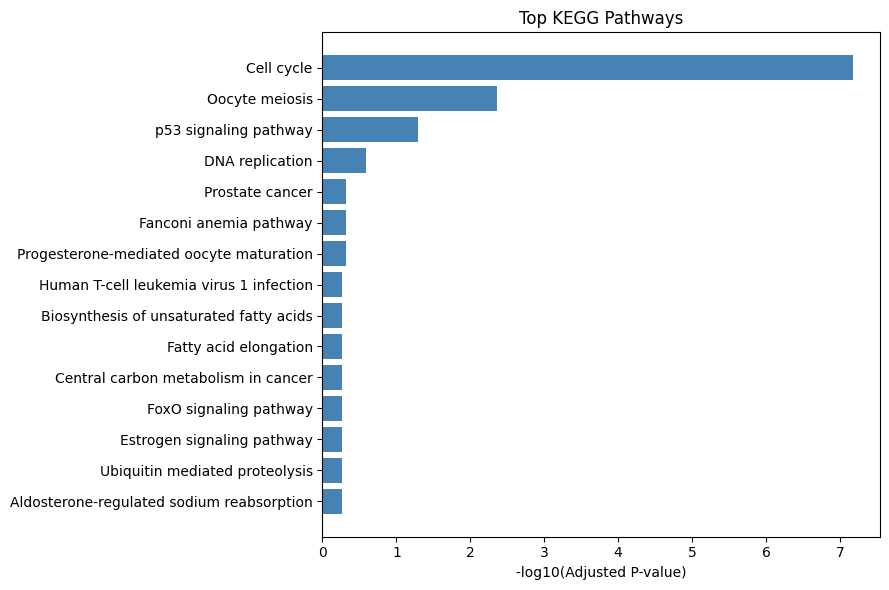

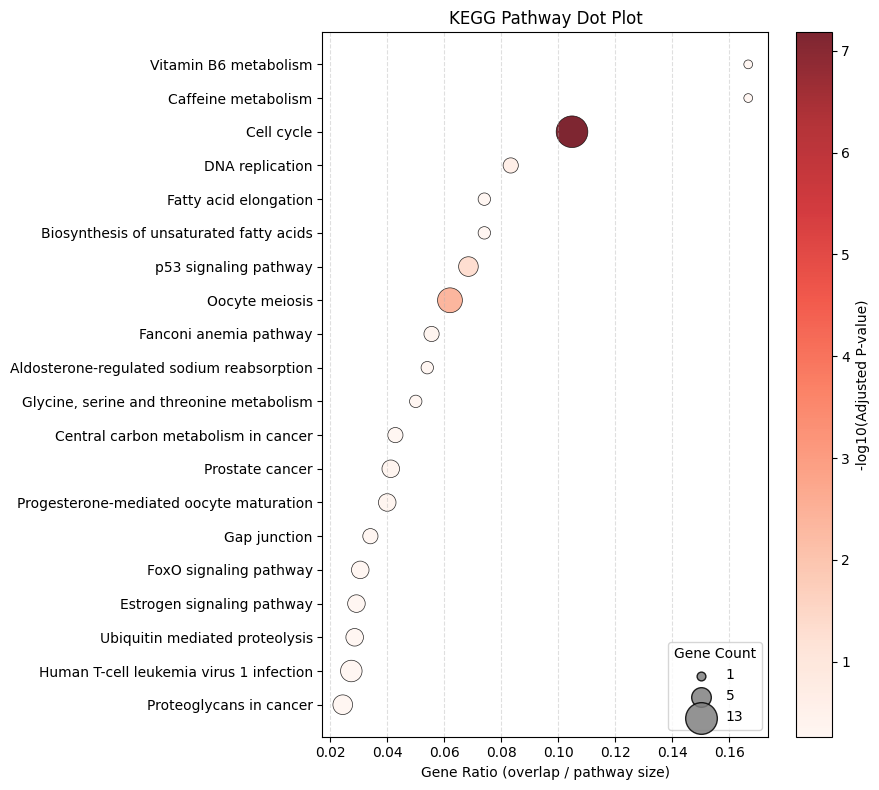

In [11]:
SEED = 777

X = gene_data
y = y_model_labels

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    random_state=SEED,
    n_jobs=-1,
    oob_score=True
)
rf.fit(X, y)

importances = rf.feature_importances_

feature_importance_df = pd.DataFrame({
    "gene": X.columns,
    "gini_importance": importances
}).sort_values(by="gini_importance", ascending=False).reset_index(drop=True)

os.makedirs("./key_genes", exist_ok=True)
feature_importance_df.to_csv("./key_genes/gini_importance_full.csv", index=False)

def clean_gene_name(name: str) -> str:
    return name.replace(".", "-")

TOP_N = 200
top_genes_raw = feature_importance_df["gene"].head(TOP_N).tolist()
top_genes_clean = [clean_gene_name(g) for g in top_genes_raw]



enr = gp.enrichr(
    gene_list=top_genes_clean,
    gene_sets=[
        "KEGG_2021_Human",
    ],
    organism="human",
    outdir=None,
    cutoff=0.05,
)

result_df = enr.results.sort_values("Adjusted P-value").reset_index(drop=True)
result_df.to_csv("./key_genes/enrichment_full.csv", index=False)


brca_keywords = [
    "breast cancer", "estrogen", "erbb", "pi3k", "cell cycle",
    "mtor", "p53", "her2", "apoptosis"
]
mask = result_df["Term"].str.lower().str.contains("|".join(brca_keywords))
brca_relevant = result_df[mask]


matched_genes = set()
for genes_str in result_df["Genes"]:
    matched_genes.update(genes_str.split(";"))

match_rate = len(matched_genes & set(top_genes_clean)) / len(top_genes_clean)


kegg_only = result_df[result_df["Gene_set"] == "KEGG_2021_Human"].head(15).copy()
kegg_only["-log10(padj)"] = -np.log10(kegg_only["Adjusted P-value"])

plt.figure(figsize=(9, 6))
plt.barh(kegg_only["Term"], kegg_only["-log10(padj)"], color="steelblue")
plt.xlabel("-log10(Adjusted P-value)")
plt.title(f"Top KEGG Pathways")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("./key_genes/top_kegg_pathways.png", dpi=150)
plt.show()



dotplot_df = result_df[result_df["Gene_set"] == "KEGG_2021_Human"].head(20).copy()
overlap_split = dotplot_df["Overlap"].str.split("/", expand=True).astype(int)
dotplot_df["Count"] = overlap_split[0]
dotplot_df["Pathway_size"] = overlap_split[1]
dotplot_df["Gene_ratio"] = dotplot_df["Count"] / dotplot_df["Pathway_size"]
dotplot_df["-log10(padj)"] = -np.log10(dotplot_df["Adjusted P-value"])
dotplot_df = dotplot_df.sort_values("Gene_ratio", ascending=True)
 
fig, ax = plt.subplots(figsize=(9, 8))
 
scatter = ax.scatter(
    x=dotplot_df["Gene_ratio"],
    y=dotplot_df["Term"],
    s=dotplot_df["Count"] * 40,        
    c=dotplot_df["-log10(padj)"],      
    cmap="Reds",
    edgecolors="black",
    linewidths=0.5,
    alpha=0.85,
)
 
ax.set_xlabel("Gene Ratio (overlap / pathway size)")
ax.set_title(f"KEGG Pathway Dot Plot")
ax.grid(axis="x", linestyle="--", alpha=0.4)
 
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("-log10(Adjusted P-value)")
 
count_values = sorted(dotplot_df["Count"].unique())
legend_counts = sorted(set([
    count_values[0],
    count_values[len(count_values) // 2],
    count_values[-1]
]))
legend_handles = [
    plt.scatter([], [], s=c * 40, color="gray", edgecolors="black", alpha=0.85, label=str(c))
    for c in legend_counts
]
ax.legend(
    handles=legend_handles,
    title="Gene Count",
    loc="lower right",
    frameon=True,
)
 
plt.tight_layout()
plt.savefig("./key_genes/kegg_dotplot.png", dpi=150)
plt.show()